In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np

path = "/tf/projet/Dataset_Livrable_2"

#list number of files in the directory
def list_files(path):
    import os
    files = os.listdir(path)
    print(f"Number of files in {path}: {len(files)}")
    return files
list_files(path)


# Load the /path images
def load_images(path, test_size=0.2):
    import os
    from PIL import Image
    import numpy as np

    images = []
    for filename in os.listdir(path):
        if filename.endswith(".jpg") or filename.endswith(".png"):
            img = Image.open(os.path.join(path, filename))
            img = img.resize((176, 176))  # Resize to a fixed size
            images.append(np.array(img))
            images_train = images[:int(len(images) * (1 - test_size))]
            images_test = images[int(len(images) * (1 - test_size)):]
    images_train = np.array(images_train)
    images_test = np.array(images_test)
    

    return images_train, images_test


Number of files in /tf/projet/Dataset_Livrable_2: 148


In [ ]:
x_train, x_test = load_images(path)
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

Commençons par écrire une fonction qui permet de visualiser $n$ premiers enregistrements en noir et blanc. 

In [ ]:
import matplotlib.pyplot as plt

def display_image(X, n):
    plt.figure(figsize=(20, 2))
    for i in range(n):
        ax = plt.subplot(1, n, i + 1)
        plt.imshow(X[i])
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)
    plt.show()

Voyons ce que ça donne :

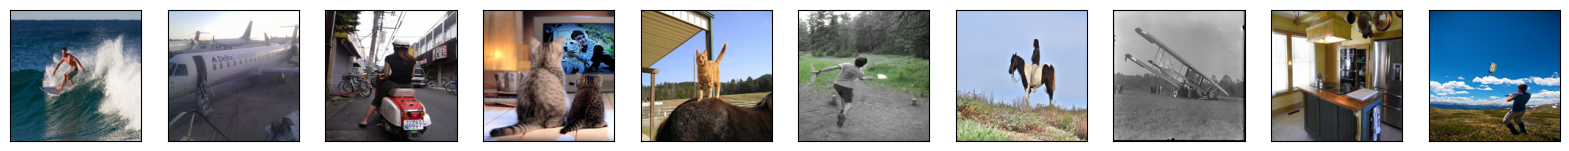

In [ ]:
display_image(x_train, n=10)

## 1.3 Auto-encodeur de réduction de bruit (denoiser)

Etant donné que le dataset ne contient pas d'images bruitées, nous allons générer un bruit aléatoire gaussian sur les images. Plus précisément, on va générer un bruit aléatoire *x_train_noisy* et *x_test_noisy* à partir de *x_train* et *x_test*

*Tip* : utiliser la méthode *normal* de *np.random*

In [ ]:
# create train_noisy and test_noisy
print(x_train.shape)
def add_noise(images, noise_factor=0.2):
    noisy_images = images + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=images.shape)
    noisy_images = np.clip(noisy_images, 0., 1.)
    return noisy_images
x_train_noisy = add_noise(x_train)
x_test_noisy = add_noise(x_test)




(118, 180, 180, 3)


Visualisez les images d'origines puis les images bruitées.

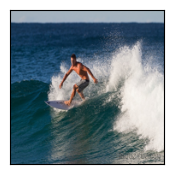

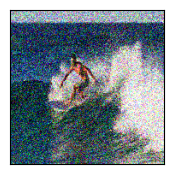

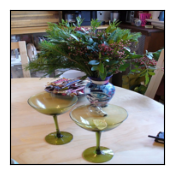

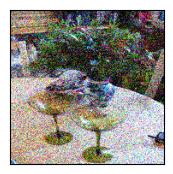

In [ ]:
display_image(x_train, n=1)
display_image(x_train_noisy, n=1)
display_image(x_test, n=1)
display_image(x_test_noisy, n=1)



In [ ]:
# Configurations principales de nos modèles
IMG_SIZE          = 176                # taille coté final d'une image en pixel (ici 28x28)
NB_EPOCHS_DENOISE = 20               # nombre epoch alogithme debruiter
BATCH_SIZE        = 256               # taille batch de traitement
SAV_MODEL_DENOISE = "denoiser.h5"     # sauvegarde du modele de debruitage

###### Encodeur

Il faut maintenant écrire un code qui permet d'encoder une image en utilisant trois couches de convolution.

*Tip* : Utiliser la classe Input, Conv2D, MaxPooling2D et UpSampling2D

In [ ]:
from keras.layers import Input, Dense, Conv2D, MaxPooling2D, UpSampling2D


# The encoding process
input_img = Input(shape=(IMG_SIZE, IMG_SIZE, 3)) # input image dimensions

# Encoding #

# Conv1
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
# kernel_size: Specifying the height and width of the 2D convolution window.
x = MaxPooling2D(pool_size=(2, 2), padding='same')(x)

# Conv 2
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D(pool_size=(2, 2), padding='same')(x)

# Conv 3
x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D(pool_size=(2, 2), padding='same')(x)



# Note:
# padding is a hyper-arameter for either 'valid' or 'same'. 
# "valid" means "no padding". 
# "same" results in padding the input such that the output has the same length as the original input.

###### Décodeur

Passon au décodeur. Écrivez un code qui permet de décoder une image encodée selon l'architecture du réseau de neurones décrite auparavent. 

In [ ]:
# Decoding #

# DeConv2
x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D(size=(2, 2))(x)


# DeConv3
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D(size=(2, 2))(x)

# DeConv4
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D(size=(2, 2))(x)

# Deconv5
decoded = Conv2D(3, (3, 3), activation= 'relu', padding='same')(x)


In [ ]:
from tensorflow.keras.models import Model
# Declare the model
autoencoder = Model(inputs=input_img, outputs=decoded)
autoencoder.compile(optimizer='adam', loss="binary_crossentropy", metrics=['accuracy'])
autoencoder.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 180, 180, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 90, 90, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 90, 90, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 45, 45, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 23, 23, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_13 (UpSampling2D) │ (None, 46, 46, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 46, 46, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_14 (UpSampling2D) │ (None, 92, 92, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 92, 92, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_15 (UpSampling2D) │ (None, 184, 184, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 184, 184, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,955 (1.27 MB)

 Trainable params: 333,955 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

###### Entrainement de l'auto-encodeur

On va ensuite entraîner l'auto-encodeur en utilisant les constantes définit au début (`NB_EPOCHS_DENOISE,BATCH_SIZE`)

In [ ]:
%load_ext tensorboard

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [ ]:
# Train the model
history = None

history = autoencoder.fit(x_train_noisy, x_train,
                epochs=NB_EPOCHS_DENOISE,
                batch_size=BATCH_SIZE,
                shuffle=True,
                validation_data=(x_test_noisy, x_test),
                verbose=1)

Epoch 1/5


I0000 00:00:1744792313.451740   63740 service.cc:146] XLA service 0x7f5c0c20a670 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1744792313.451806   63740 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6
2025-04-16 08:31:53.501316: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-04-16 08:31:53.719166: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8906
2025-04-16 08:31:58.818647: W external/local_tsl/tsl/framework/bfc_allocator.cc:291] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.35GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-04-16 08:32:13.687104: W external/local_tsl/tsl/framework/bfc_allocator

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23s/step - accuracy: 0.1974 - loss: 4.6010

I0000 00:00:1744792334.692734   63740 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1/1 ━━━━━━━━━━━━━━━━━━━━ 26s 26s/step - accuracy: 0.1974 - loss: 4.6010 - val_accuracy: 0.3483 - val_loss: 3.0061
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 0.3905 - loss: 2.9993 - val_accuracy: 0.2204 - val_loss: 2.8365
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 0.1993 - loss: 2.8321 - val_accuracy: 0.2138 - val_loss: 2.7506
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.1896 - loss: 2.7469 - val_accuracy: 0.2129 - val_loss: 2.8546
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.1866 - loss: 2.8625 - val_accuracy: 0.2176 - val_loss: 1.8110


Affichez maintenant la courbe d'apprentissage. Que pensez-vous des performances du modèle ?

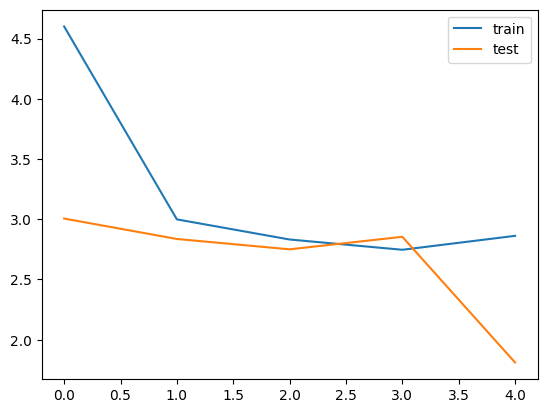

In [ ]:
# Visualisation des pertes d'apprentissage (Train) et de validation (Test)
plt.plot(history.history['loss'],
         label='train')
plt.plot(history.history['val_loss'],
         label='test')
plt.legend()

Que pensez-vous des performances du modèle ?
<em>À COMPLÉTER</em>


# 1.4 Sauvgarde de l'auto-encodeur

L'entrainement de l'auto-encodeur sans utilisation de puissance de calcul (GPU) peut prendre beaucoup de temps. Usuellement, nous sauvegardons le modèle entraîné en local ou sur un serveur distant pour l'utiliser ultérieurement afin de traiter les nouvelles données (d'ailleurs, vous verrez une utilisation avancée de cette technique, le transfert learning, dès la semaine prochaine).
Pour sauvegarder le modèle `autoencoder`, utiliser la méthode `save`.

In [ ]:
# save the model
autoencoder.save(SAV_MODEL_DENOISE)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 704ms/step


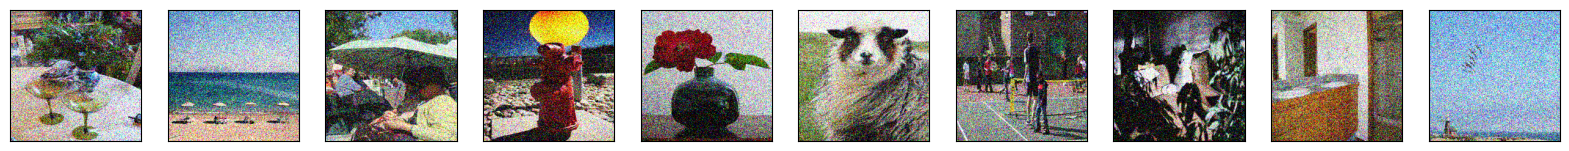

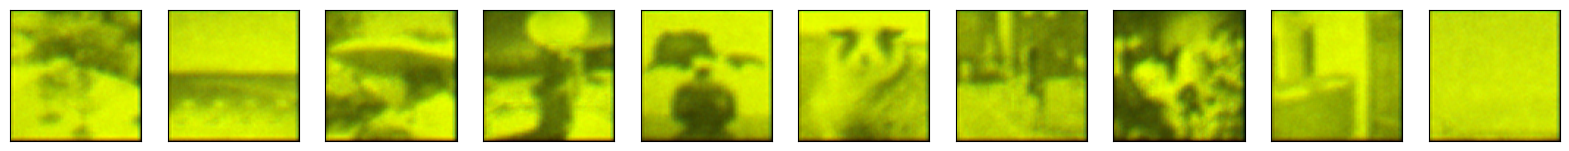

In [ ]:
decoded_imgs = autoencoder.predict(x_test_noisy)
display_image(x_test_noisy, n=10)
display_image(decoded_imgs, n=10)


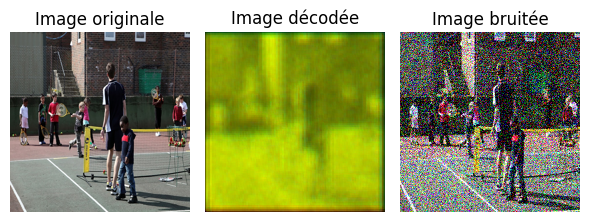

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(6, 3))
axes[0].imshow(x_test[6].squeeze(), cmap='gray', vmin=0, vmax=1)
axes[0].set_title("Image originale")
axes[0].axis("off")
axes[1].imshow(decoded_imgs[6].squeeze(), cmap='gray', vmin=0, vmax=1)
axes[1].set_title("Image décodée")
axes[1].axis("off")
axes[2].imshow(x_test_noisy[6].squeeze(), cmap='gray', vmin=0, vmax=1)
axes[2].set_title("Image bruitée")
axes[2].axis("off")
plt.tight_layout()
plt.show()
